In [11]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "optuna>=4,<5" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "cloudpickle>=3,<4"

In [12]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import math
import cloudpickle
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
WANDB_GROUP = "nbeats-final-optuna-tuning"

DATA_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/walmart_competition_data"),
    Path("/content/drive/My Drive/walmart_competition_data"),
    Path("/content/walmart_competition_data"),
    Path("../../data"),
    Path("data"),
]

OUTPUT_DIR = (
    Path("/content/artifacts/nbeats_final_optuna")
    if Path("/content").exists()
    else Path("artifacts/nbeats_final_optuna")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "validation_weeks": 32,
    "context_length": 52,
    "forecast_horizon": 32,
    "min_series_length": 84,
    "max_epochs": 45,
    "early_stopping_patience": 7,
    "num_blocks": 4,
    "num_layers": 4,
    "holiday_weight": 5.0,
    "clip_grad_norm": 1.0,
    "num_workers": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

OPTUNA_N_TRIALS = 24
OPTUNA_TIMEOUT = None

OPTUNA_SEARCH_SPACE = {
    "optimizer": ["adamw"],
    "loss_type": ["regular_l1", "holiday_weighted_l1"],
    "batch_size": [128, 256],
    "learning_rate": (3e-4, 2e-3),
    "hidden_units": [128, 192, 256, 320],
    "num_blocks": [2, 3, 4],
    "num_layers": [2, 3, 4],
    "dropout": (0.05, 0.20),
    "weight_decay": (1e-6, 3e-4),
}

BASELINE_REFERENCE_WMAE = 2157.9829
EXPERIMENT_1_WMAE = 2186.5015
EXPERIMENT_2_WMAE = 2662.8061
EXPERIMENT_3_WMAE = 2185.1366


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
print(f"Using device: {CONFIG['device']}")
print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")

Using device: cuda
Python: 3.12.13
Torch: 2.11.0+cu128


## 2. Load data

In [14]:
def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and (candidate / "train.csv").exists():
            return candidate
    searched = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find train.csv. Searched:\n{searched}")


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
print(f"Data directory: {DATA_DIR}")

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train_cols = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
missing_cols = required_train_cols.difference(train_raw.columns)
if missing_cols:
    raise ValueError(f"train.csv is missing required columns: {sorted(missing_cols)}")

print("train shape:", train_raw.shape)
print("test shape:", test_raw.shape)
print("features shape:", features_raw.shape)
print("stores shape:", stores_raw.shape)
print(
    "date range:", train_raw["Date"].min().date(), "to", train_raw["Date"].max().date()
)

Data directory: /content/drive/MyDrive/walmart_competition_data
train shape: (421570, 5)
test shape: (115064, 4)
features shape: (8190, 12)
stores shape: (45, 3)
date range: 2010-02-05 to 2012-10-26


In [15]:
train_df = train_raw.copy()
train_df["Store"] = train_df["Store"].astype(int)
train_df["Dept"] = train_df["Dept"].astype(int)
train_df = train_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

all_dates = pd.date_range(train_df["Date"].min(), train_df["Date"].max(), freq="W-FRI")
sales_pivot = (
    train_df.pivot_table(
        index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum"
    )
    .reindex(columns=all_dates)
    .sort_index()
)

holiday_by_date = (
    train_df.groupby("Date")["IsHoliday"]
    .max()
    .reindex(all_dates)
    .fillna(False)
    .astype(bool)
)

context_length = CONFIG["context_length"]
forecast_horizon = CONFIG["forecast_horizon"]
validation_weeks = CONFIG["validation_weeks"]
min_required_weeks = context_length + forecast_horizon

valid_series_mask = sales_pivot.notna().sum(axis=1) >= min_required_weeks
sales_pivot = sales_pivot.loc[valid_series_mask]
filled_sales = sales_pivot.ffill(axis=1).bfill(axis=1).fillna(0.0)

series_index = filled_sales.index
series_keys = pd.DataFrame(series_index.tolist(), columns=["Store", "Dept"])

if validation_weeks != forecast_horizon:
    raise ValueError(
        "This notebook expects validation_weeks to equal forecast_horizon."
    )

validation_start = len(all_dates) - validation_weeks
if validation_start < context_length:
    raise ValueError(
        "Not enough historical weeks before validation. Reduce context_length or validation_weeks."
    )

train_dates = all_dates[:validation_start]
validation_dates = all_dates[validation_start:]

sales_values_original = filled_sales.to_numpy(dtype=np.float32)
log_sales_values = np.log1p(
    np.clip(sales_values_original, a_min=0.0, a_max=None)
).astype(np.float32)

series_center = log_sales_values[:, :validation_start].mean(axis=1, keepdims=True)
series_scale = log_sales_values[:, :validation_start].std(axis=1, keepdims=True)
series_scale = np.where(series_scale < 1e-6, 1.0, series_scale).astype(np.float32)
normalized_values = ((log_sales_values - series_center) / series_scale).astype(
    np.float32
)

print("weekly dates:", len(all_dates))
print("usable Store-Dept series:", len(series_index))
print("training date range:", train_dates.min().date(), "to", train_dates.max().date())
print(
    "validation date range:",
    validation_dates.min().date(),
    "to",
    validation_dates.max().date(),
)
print("sales tensor shape:", normalized_values.shape)

weekly dates: 143
usable Store-Dept series: 2921
training date range: 2010-02-05 to 2012-03-16
validation date range: 2012-03-23 to 2012-10-26
sales tensor shape: (2921, 143)


In [16]:
def make_training_windows(
    values: np.ndarray,
    horizon_weights: np.ndarray,
    context: int,
    horizon: int,
    validation_start_idx: int,
):
    X_windows = []
    y_windows = []
    weight_windows = []
    last_window_start = validation_start_idx - context - horizon
    if last_window_start < 0:
        raise ValueError(
            "Not enough history to create training windows before validation."
        )

    for series_id in range(values.shape[0]):
        for start in range(last_window_start + 1):
            split = start + context
            target_slice = slice(split, split + horizon)
            X_windows.append(values[series_id, start:split])
            y_windows.append(values[series_id, target_slice])
            weight_windows.append(horizon_weights[target_slice])

    return (
        np.asarray(X_windows, dtype=np.float32),
        np.asarray(y_windows, dtype=np.float32),
        np.asarray(weight_windows, dtype=np.float32),
    )


all_horizon_weights = np.where(
    holiday_by_date.to_numpy(dtype=bool),
    CONFIG["holiday_weight"],
    1.0,
).astype(np.float32)

X_train, y_train, train_target_weights = make_training_windows(
    normalized_values,
    all_horizon_weights,
    context_length,
    forecast_horizon,
    validation_start,
)

X_val = normalized_values[
    :, validation_start - context_length : validation_start
].astype(np.float32)
y_val_original = sales_values_original[
    :, validation_start : validation_start + forecast_horizon
].astype(np.float32)
val_holiday_flags = holiday_by_date.loc[validation_dates].to_numpy(dtype=bool)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("train_target_weights:", train_target_weights.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val_original.shape)
print("validation holiday weeks:", int(val_holiday_flags.sum()))

X_train: (81788, 52)
y_train: (81788, 32)
train_target_weights: (81788, 32)
X_val: (2921, 52)
y_val: (2921, 32)
validation holiday weeks: 1


## 4. Log preprocessing to W&B

In [17]:
wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)

preprocessing_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_preprocessing",
    name="NBEATS_Final_Optuna_Preprocessing",
    config={
        **CONFIG,
        "seed": SEED,
        "model_family": "N-BEATS",
        "experiment_type": "final_optuna_hyperparameter_tuning",
        "data_dir": str(DATA_DIR),
        "train_rows": int(len(train_raw)),
        "test_rows": int(len(test_raw)),
        "usable_series": int(len(series_index)),
        "train_windows": int(len(X_train)),
        "total_weeks": int(len(all_dates)),
        "train_start_date": str(train_dates.min().date()),
        "train_end_date": str(train_dates.max().date()),
        "validation_start_date": str(validation_dates.min().date()),
        "validation_end_date": str(validation_dates.max().date()),
        "target_transform": "clip_negative_then_log1p",
        "series_scaling": "per_series_standardization_fit_on_training_period",
        "optuna_n_trials": OPTUNA_N_TRIALS,
        "optuna_timeout": OPTUNA_TIMEOUT,
        "search_space": OPTUNA_SEARCH_SPACE,
    },
)
preprocessing_run.log(
    {
        "final_optuna/usable_series": len(series_index),
        "final_optuna/train_windows": len(X_train),
    }
)
preprocessing_run.finish()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▂▃▅▆▇█
learning_rate,▁▁▁▁▁▁▁
train/loss,█▄▃▂▂▁▁
validation/mae,█▅▅▄▅▁▁
validation/rmse,█▄▄▃▄▁▁
validation/weighted_mae,█▄▄▃▅▁▁
epoch,7
learning_rate,0.00013
train/loss,0.50591
validation/mae,2202.4812
validation/rmse,4539.16895


final_optuna/train_windows,▁
final_optuna/usable_series,▁
final_optuna/train_windows,81788
final_optuna/usable_series,2921


## 5. Model, dataset, and metric definitions

In [18]:
class WindowDataset(Dataset):
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray | None = None,
        weights: np.ndarray | None = None,
    ):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.float32))
        self.weights = (
            None if weights is None else torch.from_numpy(weights.astype(np.float32))
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        if self.weights is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.weights[idx]


class NBeatsBlock(nn.Module):
    def __init__(
        self,
        input_size: int,
        horizon: int,
        hidden_units: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        layers = []
        current_size = input_size
        for _ in range(num_layers):
            layers.append(nn.Linear(current_size, hidden_units))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            current_size = hidden_units
        self.net = nn.Sequential(*layers)
        self.backcast_head = nn.Linear(hidden_units, input_size)
        self.forecast_head = nn.Linear(hidden_units, horizon)

    def forward(self, x):
        hidden = self.net(x)
        return self.backcast_head(hidden), self.forecast_head(hidden)


class NBeats(nn.Module):
    def __init__(
        self,
        input_size: int,
        horizon: int,
        hidden_units: int,
        num_blocks: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        self.horizon = horizon
        self.blocks = nn.ModuleList(
            [
                NBeatsBlock(input_size, horizon, hidden_units, num_layers, dropout)
                for _ in range(num_blocks)
            ]
        )

    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.size(0), self.horizon, device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast


def inverse_transform_predictions(
    pred_normalized: np.ndarray, center: np.ndarray, scale: np.ndarray
) -> np.ndarray:
    pred_log = pred_normalized * scale + center
    pred_sales = np.expm1(pred_log)
    return np.clip(pred_sales, a_min=0.0, a_max=None)


def weighted_mae(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    holiday_flags: np.ndarray,
    holiday_weight: float = 5.0,
) -> float:
    weights = np.where(holiday_flags.reshape(1, -1), holiday_weight, 1.0)
    weights = np.broadcast_to(weights, y_true.shape)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def regular_l1_loss(
    prediction: torch.Tensor, target: torch.Tensor, weights: torch.Tensor
) -> torch.Tensor:
    return torch.mean(torch.abs(prediction - target))


def holiday_weighted_l1_loss(
    prediction: torch.Tensor, target: torch.Tensor, weights: torch.Tensor
) -> torch.Tensor:
    return (torch.abs(prediction - target) * weights).sum() / weights.sum()

## 6. Seasonal naive reference

In [19]:
seasonal_naive_pred = sales_values_original[
    :, validation_start - forecast_horizon : validation_start
]
baseline_wmae = weighted_mae(
    y_val_original, seasonal_naive_pred, val_holiday_flags, CONFIG["holiday_weight"]
)
baseline_mae = mae(y_val_original, seasonal_naive_pred)
baseline_rmse = rmse(y_val_original, seasonal_naive_pred)

print(f"Seasonal naive validation WMAE: {baseline_wmae:.4f}")
print(f"Seasonal naive validation MAE: {baseline_mae:.4f}")
print(f"Seasonal naive validation RMSE: {baseline_rmse:.4f}")

Seasonal naive validation WMAE: 3902.8521
Seasonal naive validation MAE: 3946.3479
Seasonal naive validation RMSE: 10482.2129


## 7. Final Optuna hyperparameter tuning

This rerun uses 24 focused Optuna trials around the strong baseline region. Trial 0 explicitly reproduces the baseline configuration, so tuning cannot miss it by random sampling. The search uses AdamW, tests 2–4 blocks, 2–4 layers, 128–320 hidden units, two batch sizes, regular versus holiday-weighted L1, and a narrower learning-rate range. Each trial can train for 45 epochs with early stopping, gradient clipping, and ReduceLROnPlateau. The objective remains leakage-safe validation WMAE on the original sales scale.


In [20]:
def evaluate_model(model: nn.Module, X: np.ndarray, batch_size: int = 512):
    model.eval()
    predictions = []
    loader = DataLoader(
        WindowDataset(X), batch_size=batch_size, shuffle=False, num_workers=0
    )
    with torch.no_grad():
        for batch_X in loader:
            batch_X = batch_X.to(CONFIG["device"])
            predictions.append(model(batch_X).cpu().numpy())
    return np.concatenate(predictions, axis=0)


def suggest_params(trial: optuna.Trial) -> dict:
    return {
        "optimizer": trial.suggest_categorical(
            "optimizer", OPTUNA_SEARCH_SPACE["optimizer"]
        ),
        "loss_type": trial.suggest_categorical(
            "loss_type", OPTUNA_SEARCH_SPACE["loss_type"]
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size", OPTUNA_SEARCH_SPACE["batch_size"]
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", *OPTUNA_SEARCH_SPACE["learning_rate"], log=True
        ),
        "hidden_units": trial.suggest_categorical(
            "hidden_units", OPTUNA_SEARCH_SPACE["hidden_units"]
        ),
        "num_blocks": trial.suggest_categorical(
            "num_blocks", OPTUNA_SEARCH_SPACE["num_blocks"]
        ),
        "num_layers": trial.suggest_categorical(
            "num_layers", OPTUNA_SEARCH_SPACE["num_layers"]
        ),
        "dropout": trial.suggest_float("dropout", *OPTUNA_SEARCH_SPACE["dropout"]),
        "weight_decay": trial.suggest_float(
            "weight_decay", *OPTUNA_SEARCH_SPACE["weight_decay"], log=True
        ),
    }


def train_one_trial(
    trial_id: int,
    total_trials: int,
    trial_params: dict,
    optuna_trial: optuna.Trial | None = None,
):
    seed_everything(SEED + trial_id)
    trial_config = {**CONFIG, **trial_params}

    train_loader = DataLoader(
        WindowDataset(X_train, y_train, train_target_weights),
        batch_size=trial_config["batch_size"],
        shuffle=True,
        num_workers=trial_config["num_workers"],
        pin_memory=trial_config["device"] == "cuda",
    )

    model = NBeats(
        input_size=context_length,
        horizon=forecast_horizon,
        hidden_units=trial_config["hidden_units"],
        num_blocks=trial_params.get("num_blocks", trial_config["num_blocks"]),
        num_layers=trial_params.get("num_layers", trial_config["num_layers"]),
        dropout=trial_config["dropout"],
    ).to(trial_config["device"])

    if trial_config["optimizer"] == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
        )
    elif trial_config["optimizer"] == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
        )
    elif trial_config["optimizer"] == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
            momentum=0.9,
        )
    else:
        raise ValueError(f"Unsupported optimizer: {trial_config['optimizer']}")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
    )
    loss_fn = (
        holiday_weighted_l1_loss
        if trial_config["loss_type"] == "holiday_weighted_l1"
        else regular_l1_loss
    )

    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        group=WANDB_GROUP,
        job_type="final_optuna_trial",
        name=f"NBEATS_Final_Optuna_Trial_{trial_id:03d}",
        config={
            **trial_config,
            "seed": SEED + trial_id,
            "trial_id": trial_id,
            "total_trials": total_trials,
            "model_family": "N-BEATS",
            "experiment_type": "final_optuna_hyperparameter_tuning",
            "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
            "experiment_1_reference_weighted_mae": EXPERIMENT_1_WMAE,
            "experiment_2_reference_weighted_mae": EXPERIMENT_2_WMAE,
            "experiment_3_reference_weighted_mae": EXPERIMENT_3_WMAE,
            "train_windows": int(len(X_train)),
            "validation_series": int(len(X_val)),
        },
    )
    wandb.watch(model, log="gradients", log_freq=100)

    best_wmae = math.inf
    best_epoch = -1
    best_val_pred = None
    best_state_dict = None
    epochs_without_improvement = 0
    early_stopped = False

    for epoch in range(1, trial_config["max_epochs"] + 1):
        model.train()
        train_losses = []

        for batch_X, batch_y, batch_weights in train_loader:
            batch_X = batch_X.to(trial_config["device"])
            batch_y = batch_y.to(trial_config["device"])
            batch_weights = batch_weights.to(trial_config["device"])

            optimizer.zero_grad(set_to_none=True)
            batch_pred = model(batch_X)
            loss = loss_fn(batch_pred, batch_y, batch_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), trial_config["clip_grad_norm"])
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_pred_normalized = evaluate_model(model, X_val)
        val_pred_original = inverse_transform_predictions(
            val_pred_normalized, series_center, series_scale
        )

        validation_wmae = weighted_mae(
            y_val_original,
            val_pred_original,
            val_holiday_flags,
            trial_config["holiday_weight"],
        )
        validation_mae = mae(y_val_original, val_pred_original)
        validation_rmse = rmse(y_val_original, val_pred_original)
        scheduler.step(validation_wmae)

        run.log(
            {
                "epoch": epoch,
                "train/loss": train_loss,
                "validation/weighted_mae": validation_wmae,
                "validation/mae": validation_mae,
                "validation/rmse": validation_rmse,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        if optuna_trial is not None:
            optuna_trial.report(validation_wmae, step=epoch)
            if optuna_trial.should_prune():
                run.summary["pruned"] = True
                run.finish()
                raise optuna.TrialPruned()

        if validation_wmae < best_wmae:
            best_wmae = validation_wmae
            best_epoch = epoch
            best_val_pred = val_pred_original.copy()
            best_state_dict = {
                key: value.detach().cpu() for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Trial {trial_id + 1:03d}/{total_trials:03d} | epoch {epoch:03d}/{trial_config['max_epochs']:03d} | "
            f"optimizer={trial_config['optimizer']} loss={trial_config['loss_type']} lr={trial_config['learning_rate']:.6f} batch={trial_config['batch_size']} | "
            f"train={train_loss:.5f} val WMAE={validation_wmae:.4f} | "
            f"no improvement={epochs_without_improvement}/{trial_config['early_stopping_patience']}"
        )

        if epochs_without_improvement >= trial_config["early_stopping_patience"]:
            early_stopped = True
            print(
                f"Early stopping trial {trial_id} at epoch {epoch}. Best epoch was {best_epoch}."
            )
            break

    run.summary["best_epoch"] = best_epoch
    run.summary["best_validation_weighted_mae"] = best_wmae
    run.summary["early_stopped"] = early_stopped
    run.finish()

    return {
        "trial_id": trial_id,
        "best_epoch": best_epoch,
        "best_validation_weighted_mae": best_wmae,
        "early_stopped": early_stopped,
        "val_predictions": best_val_pred,
        "state_dict": best_state_dict,
        **trial_params,
    }


optuna_results = []
best_trial_result = None

sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=6, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=3)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

# Trial 0 reproduces the strong baseline. Optuna therefore searches from a
# known 2,157.98-WMAE region instead of hoping to sample it by chance.
study.enqueue_trial(
    {
        "optimizer": "adamw",
        "loss_type": "regular_l1",
        "batch_size": 128,
        "learning_rate": 1e-3,
        "hidden_units": 256,
        "num_blocks": 4,
        "num_layers": 4,
        "dropout": 0.10,
        "weight_decay": 1e-4,
    }
)


def objective(trial: optuna.Trial) -> float:
    global best_trial_result
    params = suggest_params(trial)
    result = train_one_trial(trial.number, OPTUNA_N_TRIALS, params, optuna_trial=trial)
    result_for_table = {
        key: value
        for key, value in result.items()
        if key not in {"val_predictions", "state_dict"}
    }
    optuna_results.append(result_for_table)

    if (
        best_trial_result is None
        or result["best_validation_weighted_mae"]
        < best_trial_result["best_validation_weighted_mae"]
    ):
        best_trial_result = result

    return result["best_validation_weighted_mae"]


study.optimize(
    objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=True
)

if best_trial_result is None:
    raise RuntimeError("Optuna did not complete any successful trials.")

optuna_results_df = (
    pd.DataFrame(optuna_results)
    .sort_values("best_validation_weighted_mae")
    .reset_index(drop=True)
)
optuna_results_path = OUTPUT_DIR / "nbeats_final_optuna_results.csv"
optuna_results_df.to_csv(optuna_results_path, index=False)

summary_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_summary",
    name="NBEATS_Final_Optuna_Tuning_Summary",
    config={
        **CONFIG,
        "optuna_n_trials": OPTUNA_N_TRIALS,
        "optuna_timeout": OPTUNA_TIMEOUT,
        "search_space": OPTUNA_SEARCH_SPACE,
        "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
        "experiment_1_reference_weighted_mae": EXPERIMENT_1_WMAE,
        "experiment_2_reference_weighted_mae": EXPERIMENT_2_WMAE,
        "experiment_3_reference_weighted_mae": EXPERIMENT_3_WMAE,
    },
)
summary_run.log(
    {
        "final_optuna/results": wandb.Table(dataframe=optuna_results_df),
        "final_optuna/best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
        "final_optuna/best_trial_id": best_trial_result["trial_id"],
    }
)
summary_run.summary["best_trial_id"] = best_trial_result["trial_id"]
summary_run.summary["best_epoch"] = best_trial_result["best_epoch"]
summary_run.summary["best_validation_weighted_mae"] = best_trial_result[
    "best_validation_weighted_mae"
]
summary_run.summary["best_params"] = study.best_params
summary_run.finish()

print("--- Final Optuna top 10 ---")
print(optuna_results_df.head(10))
print("Best Optuna params:")
print(study.best_params)
print("Best trial result:")
print(best_trial_result)

/tmp/ipykernel_1443/2797494983.py:226: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=6, multivariate=True)
[I 2026-07-16 18:47:26,445] A new study created in memory with name: no-name-485c6658-16ea-4f8d-bb3e-129712008e83


  0%|          | 0/24 [00:00<?, ?it/s]

Trial 001/024 | epoch 001/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.52566 val WMAE=2211.7457 | no improvement=0/7
Trial 001/024 | epoch 002/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.48914 val WMAE=2259.1715 | no improvement=1/7
Trial 001/024 | epoch 003/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.47685 val WMAE=2229.5276 | no improvement=2/7
Trial 001/024 | epoch 004/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.46870 val WMAE=2229.5486 | no improvement=3/7
Trial 001/024 | epoch 005/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.45551 val WMAE=2231.1204 | no improvement=4/7
Trial 001/024 | epoch 006/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.45055 val WMAE=2238.7174 | no improvement=5/7
Trial 001/024 | epoch 007/045 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.44722 val WMAE=2250.1817 | no improvement=6/7
Trial 

epoch,▁▂▃▄▅▆▇█
learning_rate,███▃▃▃▁▁
train/loss,█▅▄▃▂▂▂▁
validation/mae,▁█▃▄▄▅▆▄
validation/rmse,▁▆▃▄▄▅█▄
validation/weighted_mae,▁█▄▄▄▅▇▄
best_epoch,1
best_validation_weighted_mae,2211.74572
early_stopped,True
epoch,8
learning_rate,0.00025


[I 2026-07-16 18:48:31,747] Trial 0 finished with value: 2211.7457226888064 and parameters: {'optimizer': 'adamw', 'loss_type': 'regular_l1', 'batch_size': 128, 'learning_rate': 0.001, 'hidden_units': 256, 'num_blocks': 4, 'num_layers': 4, 'dropout': 0.1, 'weight_decay': 0.0001}. Best is trial 0 with value: 2211.7457226888064.


...

Exception ignored in: Exception ignored in: <finalize object at 0x7af2a6969740; dead><finalize object at 0x7af2a6969740; dead>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 590, in __call__
  File "/usr/lib/python3.12/weakref.py", line 590, in __call__
    return info.func(*info.args, **(info.kwargs or {}))    
return info.func(*info.args, **(info.kwargs or {}))
                 

[W 2026-07-16 19:49:12,786] Trial 3 failed with parameters: {'optimizer': 'adamw', 'loss_type': 'regular_l1', 'batch_size': 128, 'learning_rate': 0.0010986688873050883, 'hidden_units': 256, 'num_blocks': 2, 'num_layers': 4, 'dropout': 0.07772816832882906, 'weight_decay': 0.00025221951700214317} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1443/2797494983.py", line 250, in objective
    result = train_one_trial(trial.number, OPTUNA_N_TRIALS, params, optuna_trial=trial)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1443/2797494983.py", line 135, in train_one_trial
    for batch_X, batch_y, batch_weights in train_loader:
                                           ^^^^^^^^^^^^
  File "/usr/local/

     ^

KeyboardInterrupt: 

^^^^^^^^^^^^^^^^^^

## 8. Best Optuna trial diagnostics

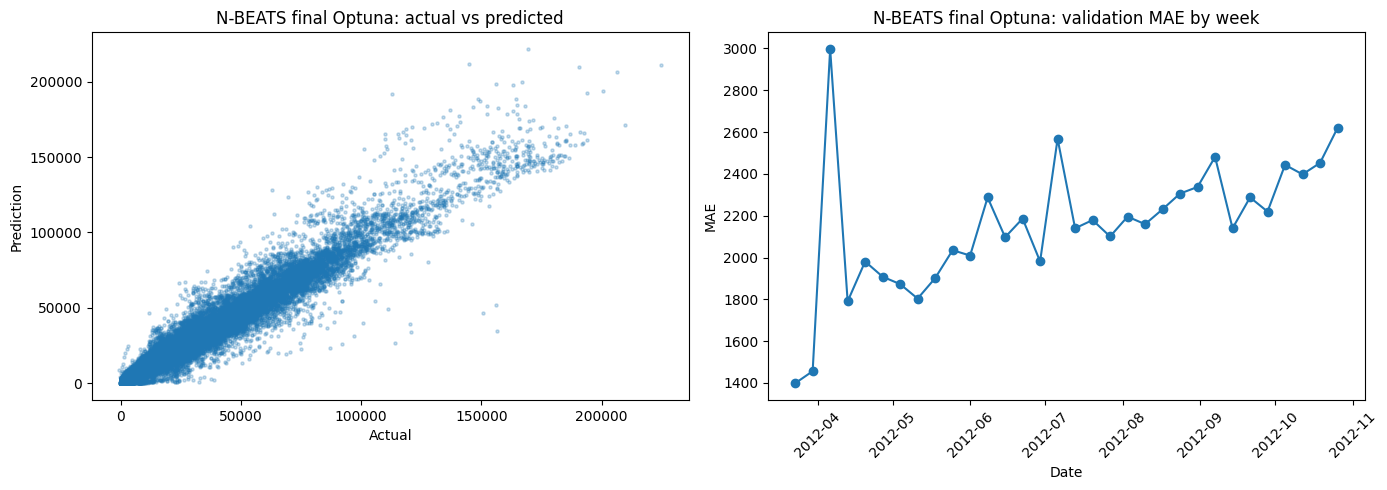

final_optuna/best_validation_weighted_mae,▁
final_optuna/best_validation_weighted_mae,2191.41167


Logged final Optuna tuning results and best-trial diagnostics to W&B.
No model artifact or Model Registry entry was created.


In [ ]:
best_val_pred_original = best_trial_result["val_predictions"]

prediction_rows = []
for series_id, (store, dept) in enumerate(series_index):
    for horizon_idx, date in enumerate(validation_dates):
        actual = float(y_val_original[series_id, horizon_idx])
        prediction = float(best_val_pred_original[series_id, horizon_idx])
        prediction_rows.append(
            {
                "Store": int(store),
                "Dept": int(dept),
                "Date": date,
                "Weekly_Sales": actual,
                "Prediction": prediction,
                "IsHoliday": bool(val_holiday_flags[horizon_idx]),
                "AbsoluteError": abs(actual - prediction),
            }
        )

val_predictions_df = pd.DataFrame(prediction_rows)
weekly_errors_df = val_predictions_df.groupby("Date", as_index=False).agg(
    Weekly_MAE=("AbsoluteError", "mean"), IsHoliday=("IsHoliday", "max")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    val_predictions_df["Weekly_Sales"],
    val_predictions_df["Prediction"],
    s=5,
    alpha=0.25,
)
axes[0].set_title("N-BEATS final Optuna: actual vs predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Prediction")

axes[1].plot(weekly_errors_df["Date"], weekly_errors_df["Weekly_MAE"], marker="o")
axes[1].set_title("N-BEATS final Optuna: validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

predictions_path = OUTPUT_DIR / "final_optuna_best_validation_predictions.csv"
weekly_errors_path = OUTPUT_DIR / "final_optuna_best_weekly_validation_errors.csv"

val_predictions_df.to_csv(predictions_path, index=False)
weekly_errors_df.to_csv(weekly_errors_path, index=False)

analysis_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_evaluation",
    name="NBEATS_Final_Optuna_Best_Trial_Evaluation",
    config={
        **CONFIG,
        "best_trial_id": best_trial_result["trial_id"],
        "best_epoch": best_trial_result["best_epoch"],
        "best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
        "best_params": study.best_params,
    },
)

evaluation_artifact = wandb.Artifact(
    name="nbeats-final-optuna-evaluation",
    type="evaluation",
    description="Final N-BEATS Optuna tuning results and best validation diagnostics. No model weights included.",
    metadata={
        "best_trial_id": int(best_trial_result["trial_id"]),
        "best_epoch": int(best_trial_result["best_epoch"]),
        "best_validation_weighted_mae": float(
            best_trial_result["best_validation_weighted_mae"]
        ),
    },
)
evaluation_artifact.add_file(
    str(optuna_results_path), name="nbeats_final_optuna_results.csv"
)
evaluation_artifact.add_file(
    str(predictions_path), name="final_optuna_best_validation_predictions.csv"
)
evaluation_artifact.add_file(
    str(weekly_errors_path), name="final_optuna_best_weekly_validation_errors.csv"
)

analysis_run.log(
    {
        "final_optuna/diagnostic_plots": wandb.Image(fig),
        "final_optuna/predictions_sample": wandb.Table(
            dataframe=val_predictions_df.head(1000)
        ),
        "final_optuna/weekly_errors": wandb.Table(dataframe=weekly_errors_df),
        "final_optuna/best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
    }
)
analysis_run.log_artifact(evaluation_artifact)
analysis_run.finish()

print("Logged final Optuna tuning results and best-trial diagnostics to W&B.")
print("No model artifact or Model Registry entry was created.")

## 9. Package and register the selected N-BEATS raw-input pipeline

The registry cell selects the best N-BEATS model for this architecture. If Optuna beats the baseline reference, it registers the best Optuna trial. If Optuna does not beat baseline, it trains and registers the baseline configuration instead, because baseline is still the best observed N-BEATS model.

The selected model is packaged as a raw-input inference pipeline. The pipeline stores trained N-BEATS weights, scaling statistics, the Store-Dept history matrix, and forecasting logic needed to call `predict(raw_test_df)` directly on unprocessed `test.csv` rows.


In [ ]:
BASELINE_PARAMS = {
    "optimizer": "adamw",
    "loss_type": "regular_l1",
    "batch_size": 128,
    "learning_rate": 1e-3,
    "hidden_units": 256,
    "num_blocks": 4,
    "num_layers": 4,
    "dropout": 0.10,
    "weight_decay": 1e-4,
    "max_epochs": 30,
    "early_stopping_patience": 30,
}

if best_trial_result["best_validation_weighted_mae"] < BASELINE_REFERENCE_WMAE:
    selected_result = best_trial_result
    selected_source = "optuna"
    selected_beats_baseline = True
else:
    print(
        "Optuna did not beat baseline. Training baseline configuration for registry packaging."
    )
    selected_result = train_one_trial(
        trial_id=OPTUNA_N_TRIALS,
        total_trials=OPTUNA_N_TRIALS + 1,
        trial_params=BASELINE_PARAMS,
        optuna_trial=None,
    )
    selected_source = "baseline_fallback"
    selected_beats_baseline = (
        selected_result["best_validation_weighted_mae"] < BASELINE_REFERENCE_WMAE
    )


class NBeatsRawPipeline:
    def __init__(
        self,
        model_state_dict: dict,
        model_params: dict,
        config: dict,
        series_index: list[tuple[int, int]],
        normalized_values: np.ndarray,
        series_center: np.ndarray,
        series_scale: np.ndarray,
        all_dates: list[pd.Timestamp],
    ):
        self.model_state_dict = model_state_dict
        self.model_params = model_params
        self.config = config
        self.series_index = [(int(store), int(dept)) for store, dept in series_index]
        self.series_to_idx = {key: idx for idx, key in enumerate(self.series_index)}
        self.normalized_values = normalized_values.astype(np.float32)
        self.series_center = series_center.astype(np.float32)
        self.series_scale = series_scale.astype(np.float32)
        self.all_dates = pd.to_datetime(all_dates)
        self.last_train_date = pd.Timestamp(self.all_dates.max())

    def _build_model(self):
        model = NBeats(
            input_size=self.config["context_length"],
            horizon=self.config["forecast_horizon"],
            hidden_units=self.model_params["hidden_units"],
            num_blocks=self.model_params["num_blocks"],
            num_layers=self.model_params["num_layers"],
            dropout=self.model_params["dropout"],
        )
        model.load_state_dict(self.model_state_dict)
        model.eval()
        return model

    def _forecast_series_until(
        self, model: nn.Module, series_id: int, max_date: pd.Timestamp
    ) -> dict[pd.Timestamp, float]:
        context_len = self.config["context_length"]
        horizon = self.config["forecast_horizon"]
        context = (
            self.normalized_values[series_id, -context_len:].astype(np.float32).copy()
        )
        current_date = self.last_train_date
        forecasts = {}

        while current_date < max_date:
            x = torch.from_numpy(context.reshape(1, -1)).float()
            with torch.no_grad():
                pred_norm = model(x).cpu().numpy()[0].astype(np.float32)

            pred_original = inverse_transform_predictions(
                pred_norm.reshape(1, -1),
                self.series_center[series_id : series_id + 1],
                self.series_scale[series_id : series_id + 1],
            )[0]

            for step in range(horizon):
                forecast_date = current_date + pd.Timedelta(weeks=step + 1)
                forecasts[pd.Timestamp(forecast_date)] = float(pred_original[step])

            context = np.concatenate([context, pred_norm])[-context_len:]
            current_date = current_date + pd.Timedelta(weeks=horizon)

        return forecasts

    def predict(self, raw_test_df: pd.DataFrame) -> np.ndarray:
        required_cols = {"Store", "Dept", "Date"}
        missing_cols = required_cols.difference(raw_test_df.columns)
        if missing_cols:
            raise ValueError(f"raw_test_df is missing columns: {sorted(missing_cols)}")

        test_df = raw_test_df.copy()
        test_df["Store"] = test_df["Store"].astype(int)
        test_df["Dept"] = test_df["Dept"].astype(int)
        test_df["Date"] = pd.to_datetime(test_df["Date"])
        max_date = pd.Timestamp(test_df["Date"].max())

        model = self._build_model()
        cache = {}
        predictions = []
        for row in test_df[["Store", "Dept", "Date"]].itertuples(index=False):
            key = (int(row.Store), int(row.Dept))
            date = pd.Timestamp(row.Date)
            series_id = self.series_to_idx.get(key)
            if series_id is None:
                predictions.append(0.0)
                continue
            if series_id not in cache:
                cache[series_id] = self._forecast_series_until(
                    model, series_id, max_date
                )
            predictions.append(max(0.0, cache[series_id].get(date, 0.0)))

        return np.asarray(predictions, dtype=np.float32)


selected_params = {
    "optimizer": selected_result["optimizer"],
    "loss_type": selected_result["loss_type"],
    "batch_size": selected_result["batch_size"],
    "learning_rate": selected_result["learning_rate"],
    "hidden_units": selected_result["hidden_units"],
    "num_blocks": selected_result.get("num_blocks", CONFIG["num_blocks"]),
    "num_layers": selected_result.get("num_layers", CONFIG["num_layers"]),
    "dropout": selected_result["dropout"],
    "weight_decay": selected_result["weight_decay"],
}

pipeline_config = {**CONFIG}
pipeline_config["max_epochs"] = int(
    selected_result.get("max_epochs", CONFIG["max_epochs"])
)
pipeline_config["early_stopping_patience"] = int(
    selected_result.get("early_stopping_patience", CONFIG["early_stopping_patience"])
)

best_pipeline = NBeatsRawPipeline(
    model_state_dict=selected_result["state_dict"],
    model_params=selected_params,
    config=pipeline_config,
    series_index=list(series_index),
    normalized_values=normalized_values,
    series_center=series_center,
    series_scale=series_scale,
    all_dates=list(all_dates),
)

pipeline_path = OUTPUT_DIR / "walmart_nbeats_raw_pipeline.pkl"
with pipeline_path.open("wb") as file:
    cloudpickle.dump(best_pipeline, file)

smoke_pred = best_pipeline.predict(test_raw.head(100))
assert len(smoke_pred) == min(100, len(test_raw))
assert np.isfinite(smoke_pred).all()

registry_target = "wandb-registry-model/Walmart_NBEATS_Pipeline"
registry_aliases = ["best-nbeats", "latest"]
registry_aliases.append("champion" if selected_beats_baseline else "candidate")

registry_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="model_registration",
    name="NBEATS_Raw_Pipeline_Registration",
    config={
        **pipeline_config,
        "registry_target": registry_target,
        "selected_source": selected_source,
        "beats_baseline": bool(selected_beats_baseline),
        "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
        "selected_validation_weighted_mae": float(
            selected_result["best_validation_weighted_mae"]
        ),
        "selected_epoch": int(selected_result["best_epoch"]),
        "selected_params": selected_params,
        "pipeline_input": "raw_test_csv",
        "pipeline_predict_signature": "predict(raw_test_df)",
        "smoke_test_rows": int(len(smoke_pred)),
    },
)

model_artifact = wandb.Artifact(
    name="walmart-nbeats-raw-pipeline",
    type="model",
    description="Raw-input N-BEATS pipeline that predicts directly from unprocessed Walmart test.csv rows.",
    metadata={
        "model_family": "N-BEATS",
        "selected_source": selected_source,
        "selected_validation_weighted_mae": float(
            selected_result["best_validation_weighted_mae"]
        ),
        "baseline_reference_weighted_mae": float(BASELINE_REFERENCE_WMAE),
        "beats_baseline": bool(selected_beats_baseline),
        "selected_epoch": int(selected_result["best_epoch"]),
        "selected_params": selected_params,
        "pipeline_file": pipeline_path.name,
    },
)
model_artifact.add_file(str(pipeline_path), name=pipeline_path.name)
model_artifact.add_file(
    str(optuna_results_path), name="nbeats_final_optuna_results.csv"
)
model_artifact.add_file(
    str(predictions_path), name="final_optuna_best_validation_predictions.csv"
)
model_artifact.add_file(
    str(weekly_errors_path), name="final_optuna_best_weekly_validation_errors.csv"
)

logged_model = registry_run.log_artifact(model_artifact, aliases=registry_aliases)
logged_model.wait()
registry_run.link_artifact(
    logged_model, target_path=registry_target, aliases=registry_aliases
)

registry_run.log(
    {
        "registry/smoke_predictions": wandb.Table(
            dataframe=pd.DataFrame({"prediction": smoke_pred[:100]})
        ),
        "registry/beats_baseline": int(selected_beats_baseline),
    }
)
registry_run.summary["registry_target"] = registry_target
registry_run.summary["registry_aliases"] = registry_aliases
registry_run.summary["selected_source"] = selected_source
registry_run.summary["beats_baseline"] = bool(selected_beats_baseline)
registry_run.finish()

print(f"Selected source: {selected_source}")
print(
    f"Selected validation WMAE: {selected_result['best_validation_weighted_mae']:.4f}"
)
print(f"Pipeline saved to: {pipeline_path}")
print(f"Linked model artifact to registry: {registry_target}")
print(f"Registry aliases: {registry_aliases}")
print(f"Beats baseline: {selected_beats_baseline}")

Optuna did not beat baseline. Training baseline configuration for registry packaging.


Trial 009/009 | epoch 001/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.52675 val WMAE=2227.7484 | no improvement=0/30
Trial 009/009 | epoch 002/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.48957 val WMAE=2258.6621 | no improvement=1/30
Trial 009/009 | epoch 003/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.47697 val WMAE=2284.2567 | no improvement=2/30
Trial 009/009 | epoch 004/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.46890 val WMAE=2254.9324 | no improvement=3/30
Trial 009/009 | epoch 005/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.46299 val WMAE=2228.0612 | no improvement=4/30
Trial 009/009 | epoch 006/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.45060 val WMAE=2243.2828 | no improvement=5/30
Trial 009/009 | epoch 007/030 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.44593 val WMAE=2224.1179 | no improvement=0/30

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,████▄▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/mae,▂▅█▅▁▃▁▆▆▅▆▅▄▂▂▂▂▃▂▃▃▃▃▂▂▂▂▂▃▃
validation/rmse,▁▆█▆▃▅▂▇▇▅▇▆▄▃▃▃▃▃▃▃▄▄▃▃▃▂▂▃▃▃
validation/weighted_mae,▁▅█▅▁▃▁▆▆▅▅▅▃▂▃▂▂▂▂▂▃▃▃▂▂▂▂▂▂▃
best_epoch,7
best_validation_weighted_mae,2224.11791
early_stopped,False
epoch,30
learning_rate,2e-05


registry/beats_baseline,▁
beats_baseline,False
registry/beats_baseline,0
registry_target,wandb-registry-model...
selected_source,baseline_fallback


Selected source: baseline_fallback
Selected validation WMAE: 2224.1179
Pipeline saved to: /content/artifacts/nbeats_final_optuna/walmart_nbeats_raw_pipeline.pkl
Linked model artifact to registry: wandb-registry-model/Walmart_NBEATS_Pipeline
Registry aliases: ['best-nbeats', 'latest', 'candidate']
Beats baseline: False


## 10. After running this notebook

Send the top Optuna rows, best trial id, best epoch, best validation WMAE, best hyperparameters, and whether the registry cell marked the model as `champion` or `candidate`. Then `n-beats.md` should be updated with whether final Optuna tuning improved the baseline.
